In [238]:
# Applied Statistics: From Data to Results (2020)

In [239]:
# I - Distributions & Probabilities

In [240]:
# 1.1 Assuming the “El Clasico” football match is an even game (p = 0.5), what is the
# probability, that the score after 144 non-draw league games is exactly even?

import numpy as np
from math import comb

'''
The score in 144 non-draw games is following Binomial(144, 0.5). "Exact draw" means 72-72 that
is P(X=72)= (144 72)(0.5)^72(0.5)^72 = (144 72)(0.5)^144 ≈ 0.0664 ~ 6.6%. 
'''

n, p = 144, 0.5
k_even = n // 2                          # 72 wins each => even (tied) score

P = comb(n, k_even) * p**n               # exact closed-form binomial probability
print(f"P(72-72) = {P:.6f} = {100*P:.3f} %")     # -> 6.638 %

# Cross-check: binomial peak height ~ sqrt(2/(pi n)) for large n
print("Gaussian approx:", np.sqrt(2/(np.pi*n)))  # -> 0.0665

P(72-72) = 0.066375 = 6.638 %
Gaussian approx: 0.06649038006690546


In [241]:
# 1.2 Brad Pitt and Edward Norton are shooting golf balls at a window with p_hit = 0.054
# chance of hitting. How many golf balls do they need to be 90% sure of hitting the window?

from math import log, ceil

'''
Probability of at least one hitting in N balls is: P(≥1 hit)= (1-(1-p_hit)^N). We want the smallest 
integer N with 1-(1-p_hit)^N≥0.90 ⇒ (1-p_hit)^N≤0.10 ⇒ N≥(ln(0.10)/ln(1-p_hit)) ⇒ N ≥ ln⁡(0.1)/ln⁡(0.946) = 41.5,
so, 42 balls (gives 90.3%, 41 balls only reach 89.7%).
'''

p_hit, conf = 0.054, 0.90
N_real = log(1 - conf) / log(1 - p_hit)   # continuous solution: 41.48
N_need = ceil(N_real)                     # round up to next whole ball: 42

print(f"N = {N_real:.2f} -> need {N_need} golf balls")
print(f"  N=41: {100*(1-(1-p_hit)**41):.2f} %")   # 89.73 % (below 90%)
print(f"  N=42: {100*(1-(1-p_hit)**42):.2f} %")   # 90.29 % (>= 90%)

N = 41.48 -> need 42 golf balls
  N=41: 89.73 %
  N=42: 90.29 %


In [242]:
# II - Error propagation

In [243]:
# 2.1 The Hubble constant h has been measured by seven independent experiments:73.5±1.4,
# 74.0 ± 1.4, 73.3 ± 1.8, 75.0 ± 2.0, 67.6 ± 0.7, 70.4 ± 1.4, and 67.66 ± 0.42 in (km/s)/Mpc.
# • What is the weighted average of h? Do the values agree with each other?
# • The first four measurements are based on a different method than the last three. Do the
# values from the same method agree with each other?

import numpy as np
from math import erf, sqrt, lgamma

'''
Using independent measurements hi​±σi the optimal (weighted) mean and its error is:
hˉ=(∑hi/σi^2)/(​∑1​/σi^2)​​ , σhˉ​ = 1 / √∑(1/σi^2​)
We review the aggrement with χ2 = ∑(hi​−hˉ)^2 / σi^2 and N-1 degrees of freedom: if p_value is small the
measuremets do not agree with each other.
'''

h   = np.array([73.5, 74.0, 73.3, 75.0, 67.6, 70.4, 67.66])
sig = np.array([1.4,  1.4,  1.8,  2.0,  0.7,  1.4,  0.42])

def weighted_average(h, s):
    w = 1 / s**2                       # inverse-variance weights
    m = np.sum(w * h) / np.sum(w)      # weighted mean
    sm = 1 / np.sqrt(np.sum(w))        # error on the weighted mean
    chi2 = np.sum((h - m)**2 / s**2)   # chi-square vs the common value
    return m, sm, chi2, len(h) - 1

def chi2_pvalue(chi2, ndf):            # survival function of the chi-square pdf
    x = np.linspace(chi2, chi2 + 2000, 400000)
    k = ndf / 2.0
    pdf = np.exp((k - 1)*np.log(x) - x/2 - (k*np.log(2) + lgamma(k)))
    return np.trapz(pdf, x)            # numpy < 2.0 -> np.trapz

m, sm, c2, ndf = weighted_average(h, sig)
print(f"ALL 7:  h = {m:.2f} +/- {sm:.2f}   chi2/ndf = {c2:.1f}/{ndf}   p = {chi2_pvalue(c2,ndf):.1e}")

# Split: first four = method A, last three = method B
mA, smA, c2A, nA = weighted_average(h[:4], sig[:4])
mB, smB, c2B, nB = weighted_average(h[4:], sig[4:])
print(f"method A: h = {mA:.2f} +/- {smA:.2f}   chi2/ndf = {c2A:.2f}/{nA}   p = {chi2_pvalue(c2A,nA):.2f}")
print(f"method B: h = {mB:.2f} +/- {smB:.2f}   chi2/ndf = {c2B:.2f}/{nB}   p = {chi2_pvalue(c2B,nB):.2f}")

# Do the two methods agree with each other?
diff = mA - mB; sdiff = sqrt(smA**2 + smB**2); z = diff/sdiff
print(f"A - B = {diff:.2f} +/- {sdiff:.2f}  ->  {z:.1f} sigma")

ALL 7:  h = 68.79 +/- 0.32   chi2/ndf = 52.5/6   p = 1.5e-09
method A: h = 73.86 +/- 0.80   chi2/ndf = 0.50/3   p = 0.92
method B: h = 67.82 +/- 0.35   chi2/ndf = 3.64/2   p = 0.16
A - B = 6.04 +/- 0.87  ->  7.0 sigma


In [244]:
# All 7 together: hˉ=68.79±0.32, but χ2/ndf=52.5/6 with p≈1.4×10^{-9} → do not agree at all. But, separately :
# method A (first 4) = 73.86 ± 0.80 with p=0.92 , method B (last 3) = 67.82±0.35 with p=0.16 → every group agree internally.
# The two methods differ by 6.0±0.96 , that is ~7σ — inconsistent with each other. That is exactly the known «Hubble tension»:
# the inconsistency comes from the two different methods, not from dispersion within each method.

In [245]:
# 2.2 Using Coulomb’s law you want to measure a charge, q0 = Fd^2/keQ. Assume that Coulomb’s constant
# ke = 8.99×10^9 Nm^2/C^2 and the instrument charge Q = 10^{−9} C are known.
# • Given force F = 0.87 ± 0.08 N and distance d = 0.0045 ± 0.0003 m, what is q0?
# • Where does the largest contribution to the uncertainty on q0 come from? F or d?
# • If you could measure F and d with uncertainties ± 0.01 N and ± 0.0001 m, respectively, at what distance
# should you expect to measure the charge in question q0 most precisely?


import numpy as np

'''
Since the type is product/power we are working with relative errors. d is squared, so its error counts twice:
σ_q0/q0 = ​​√((σ_F/F)^2 + (2*σ_d/d)^2))
'''

ke, Q = 8.99e9, 1e-9
F, sF = 0.87, 0.08
d, sd = 0.0045, 0.0003

q0 = F * d**2 / (ke * Q)
rel_F = sF / F            # relative contribution from the force
rel_d = 2 * sd / d        # relative contribution from the distance (factor 2 from d^2)
sq0 = q0 * np.sqrt(rel_F**2 + rel_d**2)

print(f"q0 = {q0:.3e} C +/- {sq0:.2e}  ({sq0/q0*100:.1f} %)")
print(f"  force term  (sF/F)^2  = {rel_F**2:.5f}")
print(f"  distance term (2sd/d)^2 = {rel_d**2:.5f}   -> distance dominates")

# Optimal distance with improved errors sF=0.01, sd=0.0001.
# q0 is a fixed real charge, so F = q0*ke*Q / d^2 changes with the measurement distance d.
sF2, sd2 = 0.01, 0.0001
A = q0 * ke * Q                        # = F*d^2, constant
dd = np.linspace(0.001, 0.02, 200000)  #Generates a table containing 200,000 possible distances, uniformly distributed from 1 mm to 2 cm. This is the "grid" of d values that we will test.
F_of_d = A / dd**2
rel = np.sqrt((sF2 / F_of_d)**2 + (2 * sd2 / dd)**2)
d_opt = dd[np.argmin(rel)]       # The function np.argmin(rel) finds the index of the smallest value in the array rel, and then dd[...] returns the corresponding distance.
print(f"optimal distance d = {d_opt:.4f} m  (min relative error {rel.min()*100:.1f} %)")

q0 = 1.960e-06 C +/- 3.17e-07  (16.2 %)
  force term  (sF/F)^2  = 0.00846
  distance term (2sd/d)^2 = 0.01778   -> distance dominates
optimal distance d = 0.0063 m  (min relative error 3.9 %)


In [246]:
# q0​=(1.96±0.32)×10−6 C, that is ~16% error. Distance is giving the largest contribution:
# (2σ_d​/d)^2 = 0.0178 against (σ_F/F)^2 = 0.0085  - more than double.
# With improved errors there is a trade-off: at large d the force becomes small (large relative error in F) 
# at small d increases the rellative error σ_d of d. The minimum occurs at d≈0.0063m (analytically,
# d_opt = 2*σ_d^2​*A^2/σ_F^2​)^1/6 with A=Fd^2.

N = 2318   mean = 0.02696   RMS = 0.00336
min = -0.01185   max = 0.03630
unphysical (x<0) mismeasurements: [-0.01185 -0.00326 -0.00208]  -> 3
low/no-Neanderthal individuals (0 <= x <= 0.015): 21
main population: N = 2286   mu = 0.02716   sigma = 0.00248
Gaussian fit chi2/ndf = 48.2/26 = 1.85


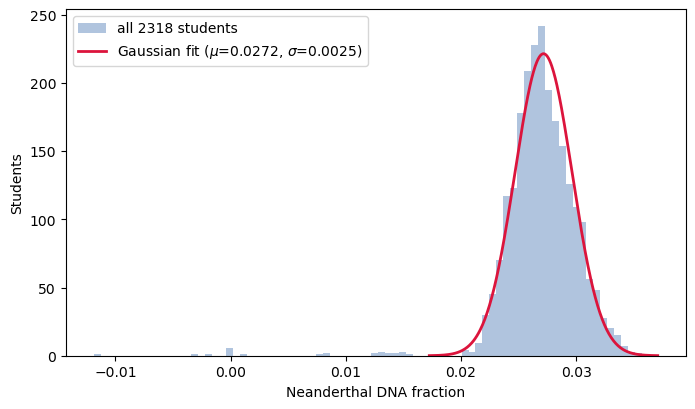

In [247]:
# 2.3 Sub-saharan humans tend not to have any Neanderthal DNA, while all others have a few percent.
# The file: www.nbi.dk/∼petersen/data DNAfraction.txt contains the fraction of Neanderthal DNA for
# 2318 Danish high school students.
# • Plot the distribution of Neanderthal DNA fraction, and calculate the mean and RMS.
# • Do you find any mismeasurements or outliers from the main population in the data?
# • Fit the main population data with distributions of your choice, and comment on the fits.

import numpy as np
import matplotlib.pyplot as plt
from math import erf
verf = np.vectorize(erf)

# Load the data
x = np.loadtxt("data/data_DNAfraction.txt")     # 2318 Neanderthal-DNA fractions
print(f"N = {x.size}   mean = {x.mean():.5f}   RMS = {x.std(ddof=1):.5f}")
print(f"min = {x.min():.5f}   max = {x.max():.5f}")

# --- Outliers / mismeasurements ---
neg = x[x < 0]                                   # negative fraction is unphysical
print(f"unphysical (x<0) mismeasurements: {np.sort(neg)}  -> {neg.size}")
low = x[(x >= 0) & (x <= 0.015)]                  # near/sub-zero: little-to-no Neanderthal DNA
print(f"low/no-Neanderthal individuals (0 <= x <= 0.015): {low.size}")

# --- Main population: iterative 3-sigma clip, then Gaussian (mean/std = MLE) ---
main = x[x > 0.015].copy()
for _ in range(5):
    mu, s = main.mean(), main.std(ddof=1)
    main = main[(main > mu - 3*s) & (main < mu + 3*s)]
mu, s = main.mean(), main.std(ddof=1)
print(f"main population: N = {main.size}   mu = {mu:.5f}   sigma = {s:.5f}")

# --- Binned chi-square goodness of fit ---
cnt, edges = np.histogram(main, bins=30)
gcdf = lambda a: 0.5*(1 + verf((a - mu)/(s*np.sqrt(2))))
exp = main.size * (gcdf(edges[1:]) - gcdf(edges[:-1]))
m = exp > 5
chi2 = np.sum((cnt[m] - exp[m])**2 / exp[m]); ndf = m.sum() - 2
print(f"Gaussian fit chi2/ndf = {chi2:.1f}/{ndf} = {chi2/ndf:.2f}")

# --- Plot (shown inline, nothing saved) ---
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(x, bins=80, color="lightsteelblue", label="all 2318 students")
xc = np.linspace(mu - 4*s, mu + 4*s, 400)
binw = (x.max() - x.min())/80
ax.plot(xc, main.size*binw*np.exp(-(xc-mu)**2/(2*s**2))/(s*np.sqrt(2*np.pi)),
        "crimson", lw=2, label=f"Gaussian fit ($\\mu$={mu:.4f}, $\\sigma$={s:.4f})")
ax.set_xlabel("Neanderthal DNA fraction"); ax.set_ylabel("Students"); ax.legend()
plt.show()

In [248]:
# III - Monte Carlo

In [249]:
# Assume that the outcome of an experiment can be described by first drawing a random number x from the distribution
# f(x) = C(c1 + x^c2) for x ∈ [1,3], where c1 = 1 and c2 = 2 and then using this x value to calculate y = x exp(−x).
# • What is the value of C? And what is the mean and RMS of f(x)?
# • What method(s) can be used to produce random numbers according to f(x)? Why?
# • Produce 5000 random numbers distributed according to f(x) and y and plot these.
# • What is the linear (Pearson) correlation betweeen the produced x and y values?
# • Fit the distribution of the produced x values to f(x), with c1 and c2 as parameters.
# • How many measurements of x would you need, in order to determine c1 and c2, respectively, with a precision better than 1% of their values?

In [250]:
# i)

import numpy as np

a, b = 1.0, 3.0
c1, c2 = 1.0, 2.0

C = 1 / ((b + b**3/3) - (a + a**3/3))                 # normalisation: 3/32
Ex = C * ((b**2/2 + b**4/4) - (a**2/2 + a**4/4))       # <x>
Ex2 = C * ((b**3/3 + b**5/5) - (a**3/3 + a**5/5))      # <x^2>
rms = np.sqrt(Ex2 - Ex**2)
print(f"C = {C:.5f}   mean = {Ex:.4f}   RMS = {rms:.4f}")   # 0.09375, 2.2500, 0.5362

C = 0.09375   mean = 2.2500   RMS = 0.5362


In [251]:
# ii)

# There are two options. The transformation method requires you to solve F(x)=u in terms of x. Here the
# CDF is cubic (∝ (x+x^3)/3) so, the inverse exists but is combersome. The accept/reject method is the
# natural choice because f is bounded on the finite interval [1,3] with a maximum f(3) = 10C = 0.9375 so,
# you uniformly sample points below the “ceiling” and keep those that fall below f.

sample mean = 2.240  RMS = 0.536  (expect 2.25, 0.536)


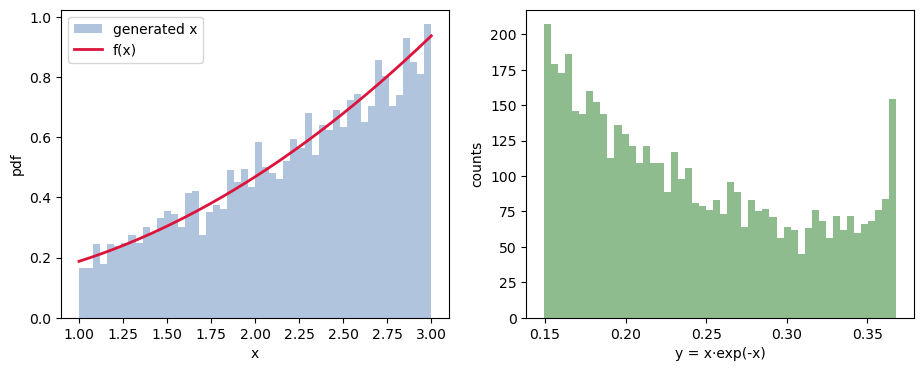

In [252]:
# iii) 

import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N, fmax = 5000, C*(c1 + b**c2)        # ceiling = f(3) = 0.9375

# Accept/reject sampling of f(x) on [1,3]
xs = []
while len(xs) < N:
    xt = rng.uniform(a, b, N)
    ut = rng.uniform(0, fmax, N)
    xs.extend(xt[ut < C*(c1 + xt**c2)])   # keep points below f(x)
x = np.array(xs[:N])
y = x * np.exp(-x)                         # transform to y

print(f"sample mean = {x.mean():.3f}  RMS = {x.std(ddof=1):.3f}  (expect 2.25, 0.536)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
xc = np.linspace(a, b, 300)
ax[0].hist(x, bins=50, density=True, color="lightsteelblue", label="generated x")
ax[0].plot(xc, C*(c1 + xc**c2), "crimson", lw=2, label="f(x)")
ax[0].set_xlabel("x"); ax[0].set_ylabel("pdf"); ax[0].legend()
ax[1].hist(y, bins=50, color="darkseagreen")
ax[1].set_xlabel("y = x·exp(-x)"); ax[1].set_ylabel("counts")
plt.show()

In [253]:
# iv)

r = np.corrcoef(x, y)[0, 1]
print(f"Pearson correlation(x, y) = {r:.4f}")    # ~ -0.998

from scipy.stats import pearsonr

r, p = pearsonr(x, y)          # returns correlation AND its p-value   (2nd way, including p-value)
print(f"Pearson r = {r:.4f}   p-value = {p:.3g}")   # large r and 0 p-value indicates strong and absolutely significant correlation

Pearson correlation(x, y) = -0.9984
Pearson r = -0.9984   p-value = 0


In [254]:
# v)

from scipy.optimize import curve_fit

def f_pdf(x, c1, c2):
    G = lambda t: c1*t + t**(c2+1)/(c2+1)     # antiderivative of (c1 + x^c2)
    return (c1 + x**c2) / (G(b) - G(a))        # normalised on [1,3]

counts, edges = np.histogram(x, bins=40, range=(a, b))
ctr = 0.5*(edges[1:] + edges[:-1]); bw = edges[1] - edges[0]
mask = counts > 0

model = lambda x, c1, c2: N * bw * f_pdf(x, c1, c2)
popt, pcov = curve_fit(model, ctr[mask], counts[mask],
                       p0=[1.0, 2.0], sigma=np.sqrt(counts[mask]),
                       absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))
chi2 = np.sum((counts[mask] - model(ctr[mask], *popt))**2 / counts[mask])
rho = pcov[0,1] / (perr[0]*perr[1])

print(f"c1 = {popt[0]:.3f} +/- {perr[0]:.3f}")
print(f"c2 = {popt[1]:.3f} +/- {perr[1]:.3f}")
print(f"chi2/ndf = {chi2:.1f}/{mask.sum()-2} = {chi2/(mask.sum()-2):.2f}")
print(f"correlation(c1, c2) = {rho:.3f}")

c1 = 0.426 +/- 0.524
c2 = 1.723 +/- 0.243
chi2/ndf = 38.6/38 = 1.02
correlation(c1, c2) = 0.976


In [255]:
# vi)

for name, val, err in zip(["c1", "c2"], popt, perr):
    N_req = N * (err / (0.01*abs(val)))**2
    print(f"{name}: need ~{N_req:,.0f} measurements for 1% precision")

c1: need ~75,857,972 measurements for 1% precision
c2: need ~993,305 measurements for 1% precision


In [256]:
# IV - Statistical tests

In [257]:
# The length (l in μm) and transparency (T) of two types of cells (P and E) can be found for 4690 cells
# in the file: www.nbi.dk/∼petersen/data Cells.txt.
# • Selecting P -cells by requiring l < 9 μm what is the rate of type I and type II errors? 
# • Which of the two variables l and T is best at distinguishing between P and E cells? 
# • Separate P and E cells using l and/or T , and draw a ROC curve of your result.

In [258]:
import numpy as np
import matplotlib.pyplot as plt

d = np.loadtxt("data/data_Cells.txt")     # columns: type(0/1), length l [um], transparency T
typ, l, T = d[:, 0], d[:, 1], d[:, 2]
P, E = typ == 0, typ == 1                 # P = small cells, E = large cells
print(f"P-cells: {P.sum()}   E-cells: {E.sum()}")

P-cells: 2574   E-cells: 2116


In [259]:
# i)

type_I  = (l[P] >= 9).sum() / P.sum()     # true P rejected by the cut
type_II = (l[E] <  9).sum() / E.sum()     # true E accepted as P
print(f"type I  (P with l>=9) = {type_I*100:.2f} %")     # 2.80 %
print(f"type II (E with l<9)  = {type_II*100:.2f} %")     # 12.71 %

type I  (P with l>=9) = 2.80 %
type II (E with l<9)  = 12.71 %


In [260]:
# ii)

def separation(a, b):
    return abs(a.mean() - b.mean()) / np.sqrt(a.std(ddof=1)**2 + b.std(ddof=1)**2)

def roc(score, is_P):
    s = score if score[is_P].mean() >= score[~is_P].mean() else -score  # high = P-like
    thr = np.sort(np.unique(s))[::-1]
    tpr = np.array([(s[is_P]  >= t).mean() for t in thr])   # P efficiency
    fpr = np.array([(s[~is_P] >= t).mean() for t in thr])   # E mistaken as P
    return fpr, tpr, np.trapz(tpr, fpr)                     # numpy < 2.0 -> np.trapz

print(f"separation  l = {separation(l[P], l[E]):.2f}   T = {separation(T[P], T[E]):.2f}")
print(f"AUC         l = {roc(l, P)[2]:.3f}   T = {roc(T, P)[2]:.3f}")

separation  l = 1.49   T = 2.22
AUC         l = 0.982   T = 0.977


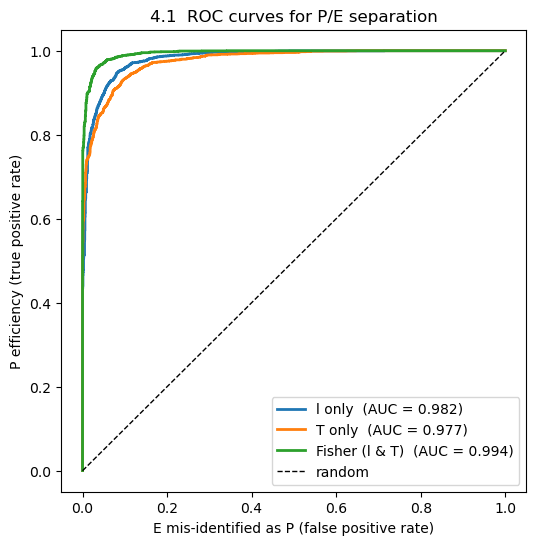

Fisher AUC = 0.994
best cut: P efficiency = 95.9%, E contamination = 3.2%


In [261]:
# iii)

# Fisher linear discriminant combining l and T
X = np.column_stack([l, T])
muP, muE = X[P].mean(0), X[E].mean(0)
Sw = np.cov(X[P].T)*(P.sum()-1) + np.cov(X[E].T)*(E.sum()-1)   # within-class scatter
w = np.linalg.solve(Sw, muP - muE)
fisher = X @ w

fig, ax = plt.subplots(figsize=(6, 6))
for score, name in [(l, "l only"), (T, "T only"), (fisher, "Fisher (l & T)")]:
    fpr, tpr, A = roc(score, P)
    ax.plot(fpr, tpr, lw=2, label=f"{name}  (AUC = {A:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax.set_xlabel("E mis-identified as P (false positive rate)")
ax.set_ylabel("P efficiency (true positive rate)")
ax.set_title("4.1  ROC curves for P/E separation"); ax.legend(loc="lower right")
plt.show()

# Best operating point of the combined classifier (Youden's J = TPR - FPR)
fpr, tpr, A = roc(fisher, P)
i = np.argmax(tpr - fpr)
print(f"Fisher AUC = {A:.3f}")
print(f"best cut: P efficiency = {tpr[i]*100:.1f}%, E contamination = {fpr[i]*100:.1f}%")

In [262]:
# V - Fitting data

In [263]:
# 5.1

# Kepler’s third law states that “the square of the orbital period (T) of a planet is directly proportional to the
# cube of the semi-major axis (a) of its orbit”. The table lists values for T in days (known very precisely) and a
# in AU (= 149597870700m) at the time of the first measurement (in 1778) of the gravitational constant
# G_1778 = (7.5 ± 1.0) × 10^−11*m^3*kg^−1*s^−2.

# Planet     Mercury     Venus        Earth         Mars      Jupiter   Saturn
# T (days)   87.77      224.70       365.25       686.95     4332.62   10759.2
# a (AU)  0.389±0.011 0.724±0.020 1(definition) 1.524±0.037 5.20±0.13  9.51±0.34

# • Plot the five non-Earth values and fit these to Kepler’s third Law: a = C × T 2/3.
# • In this fit, which planet seems to follow this relation least well? Is it critical?
# • From the value you obtain for C and G1778 estimate the solar mass M = 4π2C3/G in kg.
# • Expand the fit to Kepler’s third law by further adding two parameters: T = C × (ac1 + c2).
# Does this formula match the data well? Are the two additional parameters necessary?

C = 0.019591 +/- 0.000240 AU/day^(2/3)   chi2/ndf = 0.05/4


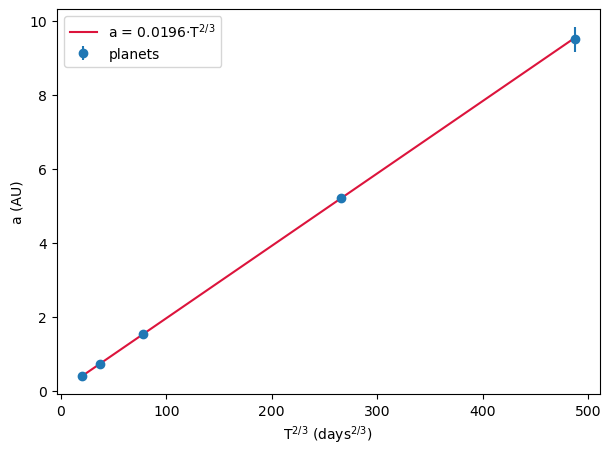

In [264]:
# i)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

planet = ["Mercury", "Venus", "Mars", "Jupiter", "Saturn"]
T  = np.array([87.77, 224.70, 686.95, 4332.62, 10759.2])    # days (Earth excluded)
a  = np.array([0.389, 0.724, 1.524, 5.20, 9.51])            # AU
sa = np.array([0.011, 0.020, 0.037, 0.13, 0.34])

kepler = lambda T, C: C * T**(2/3)
popt, pcov = curve_fit(kepler, T, a, sigma=sa, absolute_sigma=True, p0=[0.02])
C, sC = popt[0], np.sqrt(pcov[0, 0])
chi2 = np.sum(((a - kepler(T, C)) / sa)**2)
print(f"C = {C:.6f} +/- {sC:.6f} AU/day^(2/3)   chi2/ndf = {chi2:.2f}/{len(a)-1}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(T**(2/3), a, yerr=sa, fmt="o", label="planets")
tg = np.linspace(T.min(), T.max(), 200)
ax.plot(tg**(2/3), kepler(tg, C), "crimson", label=f"a = {C:.4f}·T$^{{2/3}}$")
ax.set_xlabel("T$^{2/3}$ (days$^{2/3}$)"); ax.set_ylabel("a (AU)"); ax.legend()
plt.show()

In [265]:
# ii)

for p, ai, Ti, si in zip(planet, a, T, sa):
    print(f"{p:8s}  pull = {(ai - kepler(Ti, C))/si:+.2f}")

Mercury   pull = +0.19
Venus     pull = -0.00
Mars      pull = -0.03
Jupiter   pull = -0.05
Saturn    pull = -0.11


In [266]:
# iii)

AU, day = 149597870700.0, 86400.0
C_SI = C * AU / day**(2/3)
G, sG = 7.5e-11, 1.0e-11                      # G_1778

M  = 4*np.pi**2 * C_SI**3 / G
sM = M * np.sqrt((3*sC/C)**2 + (sG/G)**2)     # error propagation
print(f"M_sun = {M:.3e} +/- {sM:.3e} kg")     # ~1.78e30 +/- 0.25e30

M_sun = 1.775e+30 +/- 2.455e+29 kg


In [267]:
# iv)

expanded = lambda a, C, c1, c2: C * (a**c1 + c2)
sT = 1.5 * (T/a) * sa                          # propagate a-errors to T (T ~ a^1.5)
popt2, pcov2 = curve_fit(expanded, a, T, sigma=sT, absolute_sigma=True, p0=[365, 1.5, 0.0])
perr2 = np.sqrt(np.diag(pcov2))
for nm, v, e in zip(["C", "c1", "c2"], popt2, perr2):
    print(f"{nm} = {v:.4f} +/- {e:.4f}")

C = 365.7209 +/- 17.9970
c1 = 1.5004 +/- 0.0325
c2 = -0.0024 +/- 0.0238


In [268]:
# 5.2

# Searching for slow moving (compared to speed of light) particles at CERN’s LHC accelerator, you are calibrating the
# speed measurement β = v/c of the candidate particles, using a control sample of particles known to (effectively)
# travel at the speed of light, i.e. β = 1.
# The file www.nbi.dk/∼petersen/data BetaCalibration.txt contains 4000 control sample measurements of initial speed
# estimate (βinit), energy (E) in GeV, angle with respect to the beam axis (θ) in radians, and time since start of
# experiment (T) in seconds, respectively.
# • What is the resolution of βinit? And is it consistent with a Gaussian distribution?
# • Is the distribution in θ consistent with being symmetric around π/2?
# • Test if the mean of βinit is constant as a function of energy.
# • Due to shifts in timing, the central value of βinit shifted with time T , smearing the resolution. Calibrate βinit with respect to T and determine the obtained resolution on βT-calib.
# • Using all information available, what is the best calibration of β you can produce?

In [269]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

d = np.loadtxt("data/data_BetaCalibration.txt")
beta, theta, E, T = d[:, 0], d[:, 1], d[:, 2], d[:, 3]   # note column order!

In [270]:
# i)

mu, res = beta.mean(), beta.std(ddof=1)
n = len(beta)
skew = np.mean((beta-mu)**3)/res**3
print(f"mean = {mu:.4f}   resolution (std) = {res:.4f}")
print(f"skewness = {skew:.2f}  ({abs(skew)/np.sqrt(6/n):.0f} sigma from 0)")

# Gaussian fit to the histogram for comparison
cnt, edges = np.histogram(beta, bins=60)
ctr = 0.5*(edges[1:]+edges[:-1]); m = cnt > 0
gauss = lambda x, A, m, s: A*np.exp(-(x-m)**2/(2*s**2))
popt, _ = curve_fit(gauss, ctr[m], cnt[m], p0=[cnt.max(), mu, res], sigma=np.sqrt(cnt[m]))
chi2 = np.sum((cnt[m]-gauss(ctr[m], *popt))**2/cnt[m])
print(f"Gaussian fit chi2/ndf = {chi2:.0f}/{m.sum()-3}")

mean = 1.0239   resolution (std) = 0.0912
skewness = -0.52  (13 sigma from 0)
Gaussian fit chi2/ndf = 422/55


In [271]:
# ii)

sem = theta.std(ddof=1)/np.sqrt(n)
print(f"(mean(theta) - pi/2)/SEM = {(theta.mean()-np.pi/2)/sem:.2f} sigma")

(mean(theta) - pi/2)/SEM = 0.44 sigma


corr(beta, E) = -0.302
chi2 vs constant = 494 / 6  -> NOT constant


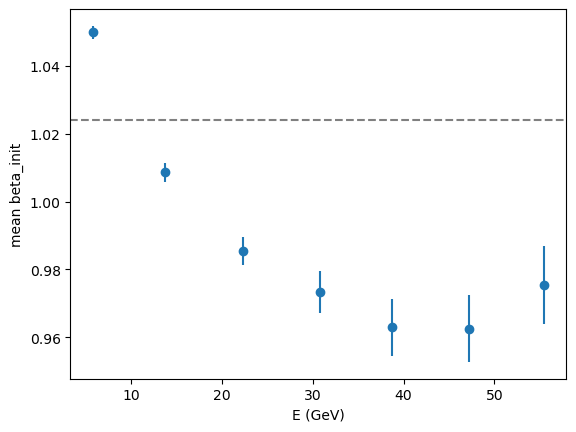

In [272]:
# iii)

bins = np.linspace(E.min(), 60, 8)
idx = np.digitize(E, bins)
Ec, bm, be = [], [], []
for b in range(1, len(bins)):
    s = idx == b
    if s.sum() > 10:
        Ec.append(E[s].mean()); bm.append(beta[s].mean()); be.append(beta[s].std()/np.sqrt(s.sum()))
Ec, bm, be = map(np.array, (Ec, bm, be))
# chi2 against a constant (the overall mean)
chi2_const = np.sum(((bm - mu)/be)**2)
print(f"corr(beta, E) = {np.corrcoef(beta, E)[0,1]:.3f}")
print(f"chi2 vs constant = {chi2_const:.0f} / {len(bm)-1}  -> NOT constant")

plt.errorbar(Ec, bm, yerr=be, fmt="o"); plt.axhline(mu, ls="--", color="grey")
plt.xlabel("E (GeV)"); plt.ylabel("mean beta_init"); plt.show()

In [273]:
# iv)

p = np.polyfit(T, beta, 1)                       # linear drift with time
beta_Tcalib = beta - np.polyval(p, T) + 1.0      # remove trend, re-center at 1
print(f"time drift slope = {p[0]:.2e} per second")
print(f"resolution: raw = {beta.std(ddof=1):.4f}  ->  T-calibrated = {beta_Tcalib.std(ddof=1):.4f}")

time drift slope = 2.05e-05 per second
resolution: raw = 0.0912  ->  T-calibrated = 0.0880


In [274]:
# v)

A = np.column_stack([np.ones_like(beta), 1/E, T])      # design matrix: const, 1/E, T
coef, *_ = np.linalg.lstsq(A, beta, rcond=None)
beta_cal = beta - A @ coef + 1.0                       # corrected, centered at 1
print("coefficients [const, 1/E, T] =", coef)
print(f"resolution: raw {beta.std(ddof=1):.4f} -> 1/E only ... -> 1/E + T = {beta_cal.std(ddof=1):.4f}")
# theta adds nothing:
A2 = np.column_stack([A, np.cos(theta)])
c2, *_ = np.linalg.lstsq(A2, beta, rcond=None)
print(f"adding cos(theta): {(beta - A2@c2).std(ddof=1):.4f}  (no improvement)")

coefficients [const, 1/E, T] = [9.35060970e-01 3.59172070e-01 2.03069069e-05]
resolution: raw 0.0912 -> 1/E only ... -> 1/E + T = 0.0810
adding cos(theta): 0.0810  (no improvement)
